# Diabetes

Som nævnt, har du fået betroet opgaven at skrive en machine learning algoritme der kan forudsiger om en person har diabetes eller ej. Før vi går i gang, skal vi have hentet nogle "pakker". Tænk på det som nogen der har skrevet noget kode vi kan importere, så vi ikke skal gøre alting fra bunden. Når du kører cellen herunder, importerer og installerer den automatisk det vi skal bruge.

In [ ]:
# Importer pakker der skal bruges
%pip install -q numpy matplotlib scikit-learn lightgbm graphviz ipython scipy

# Data
import numpy as np
import scipy as scipy

# Plotting
import matplotlib.pyplot as plt

# Sklearn: et librabry med en masse funtioner vi bruger i Machine Learning
import sklearn as sklearn

# Graphviz - Pakke der kan visualisere decision trees
from IPython.display import SVG, display
from graphviz import Source

# LightGBM - pakke til at køre decision tree
import lightgbm as lgb
from lightgbm import early_stopping

## Inspicer dataen

Først vil vi gerne undersøge hvilken data vi har med at gøre. 

In [ ]:
data = np.genfromtxt('diabetes_data.csv', delimiter=',', names=True, dtype=None, encoding=None)

variabler = data.dtype.names
input_variabler = [v for v in variabler if v != 'Diabetes']
input_data = np.column_stack([data[v] for v in input_variabler])
truth_data = data['Diabetes']

# Print first 5 rows with names
print(" | ".join(variabler))
for row in data[:5]:
    print(" | ".join(str(row[v]) for v in variabler))

# Decision Tree

Et decision tree er bygget op af lag og grene. Ved hver gren stiller den et spørgsmål, og bevæger sig ned i det næste lag baseret på om spørgsmålet er sandt eller falsk. Og ved at lære af en masse data, kan den finde ud af hvilke spørgsmål der er bedst at stille.

### Parameter
For et decision tree kan vi justere på hvor mange lag der skal være i vores træ, altså hvor mange lag af spørgsmål der må stilles. Vi kan justere på den parameter herunder.

In [3]:
DT_N_lag = 2                # Hvor mange lag der er i træet

Her bygger og træner vi modellen og bruger Graphviz til at visualisere det.

Max dybde af træet: 2


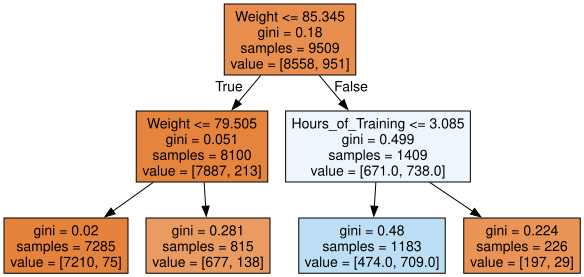

In [4]:
# Her bliver modellen trænet på data
estimator = sklearn.tree.DecisionTreeClassifier(max_depth=DT_N_lag, min_samples_leaf = 20,random_state=42)

estimator.fit(input_data, truth_data)   # Dette er den "magiske" linje - her optimerer Machine Learning algoritmen sine interne vægte til at give bedste svar

# laver visuel graf af træet
dot = sklearn.tree.export_graphviz(estimator, out_file=None, feature_names=input_variabler, filled=True, max_depth=50)         
dot = dot.replace("squared_error", "error").replace("mse", "error")
graph = Source(dot)
print("Max dybde af træet:", estimator.get_depth())
display(SVG(graph.pipe(format='svg')))


### Spørgsmål:

- Inspicer træet. Forstår du/I, hvad de forskellige tal betyder?
  Hvilken kasse falder de fleste personer ned I? Hvor er der færrest? 
  
Tallene i value er [raske, diabetikere].
- Hvilke(n) af kasserne bliver kategoriseret som at have diabetes? 
- Hvor stor en del af patienter med diabetes vil den forudsige til at have diabetes?
- Prøv at ændre på hvor mange lag der er i træet fra 2 til 3.
  Hvilken parameter bliver brugt oftest til at opdele data? Kan du/I ud fra træet sige mere generelt hvilke parametre der betyder mest for om en person har diabetes? Hvilke betyder mindst?

## Boosted Decision Tree

Nu hvor vi har set hvordan træet virker, vil vi gerne prøve at forudsige om patienter vi ikke kender diagnosen på har diabetes eller ej.
Som vi har set, kan det være svært at minimere vores 'loss function'. En måde at forbedre på er ved at køre boosted decision trees, hvilket vil sige at vi kører flere træer, hvor den hver gang lærer af fejlene fra det forrige træ, og på den måde bliver "boostet" for hvert træ den laver. Herunder kan vi ændre hvor mange gange den må "booste", altså hvor mange træer den må lave og lære af.

In [5]:
boosting_rounds = 10        # Hvor mange runder af træer den må lave og lærer af

Vi kan også vælge hvor stor en andel af data vi vil bruge. 

In [6]:
andel_af_data = 1.0  #Vælg hvor stor andel. Tallet skal være mellem 0 og 1.0.

#Vi omdefinerer vores input og truth data til kun at indeholde en del af dataene.
input_data_justeret, truth_data_justeret = sklearn.utils.resample(
    input_data, truth_data, 
    n_samples=int(andel_af_data * len(input_data)), 
    random_state=42, 
    replace=False
    )

Vi bruger train_test_split til at splitte data i et træningssæt og et testsæt.
Træningssættet bruges til at træne modellen, hvor modellen får at vide hvilke personer der har diabetes.
Testsættet bruges til at give den trænede model data uden at vide hvilke personer der har diabetes, og bagefter kan vi tjekke om dens forudsigelser var korrekte.

In [7]:
data_træning, data_test, sande_gruppe_træning, sande_gruppe_test = \
    sklearn.model_selection.train_test_split(input_data_justeret, truth_data_justeret, test_size=0.25, random_state=42)

In [ ]:
# Her bygger vi modellen op med flere træer, træner på data og forudsiger priser
# Her definerer vi beslutningsgrænsen. Som standard bruges 0.5
beslutningsgrænse = 0.5

# vi vælger 'binary' fordi vi gerne vil forudsige to klasser. 
gbm_test = lgb.LGBMClassifier(objective='binary', n_estimators=boosting_rounds, verbosity=-1) 

# Her træner vi vores model på vores trænings data
gbm_test.fit(data_træning, sande_gruppe_træning, eval_set=[(data_test, sande_gruppe_test)], 
            callbacks=[early_stopping(15)])

# Her får vi sandsynlighederne for om hver person har diabetes eller ej
forudsagte_score = gbm_test.predict_proba(data_test, num_iteration=gbm_test.best_iteration_)[:, 1]

# her får vi en liste med 0'er og 1'ere. Hvis en person har en sandsynlighed over beslutningsgrænsen, bliver den sat til 1,
# altså forudsagt som diabetiker
forudsagte_gruppe = gbm_test.predict_proba(data_test, num_iteration=gbm_test.best_iteration_)[:,1]
forudsagte_gruppe = (forudsagte_gruppe > beslutningsgrænse).astype(int)

In [9]:
#Funktion der visualiserer resultaterne
def Plotting(label_test, Forudsigelse, y_pred_label, beslutningsgrænse):

    #ROC
    #Udregn raten af sande/falske forudsigelser
    fpr, tpr, _ = sklearn.metrics.roc_curve(label_test, Forudsigelse)    
    #AUC score
    auc_score = sklearn.metrics.auc(fpr,tpr)  

    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(10, 5))

    #Plotting
    axs[0].set_title('ROC-curve', size = 10)
    axs[0].plot(fpr, tpr, label=f'(AUC = {auc_score:5.3f})')
    axs[0].plot([0, 1], [0, 1], 'r--', label='Tilfældig')
    axs[0].legend(fontsize=10, loc ='lower right')
    axs[0].set_xlabel('False Positive Rate', size=10)
    axs[0].set_ylabel('True Positive Rate', size=10)
    axs[0].grid(True, alpha=0.3)

    #Beregning af falske klassificeringer
    sandsynlighed_falsk = Forudsigelse[label_test == 0]
    sandsynlighed_korrekt = Forudsigelse[label_test == 1]
    syg_but_pred_rask_mask = (label_test == 1) & (y_pred_label == 0)
    rask_but_pred_syg_mask = (label_test == 0) & (y_pred_label == 1)
    syg_but_pred_rask = syg_but_pred_rask_mask.sum()
    rask_but_pred_syg = rask_but_pred_syg_mask.sum()
    antal_syg = (label_test == 1).sum()
    antal_rask = (label_test == 0).sum()
    pct_syg_but_pred_rask = 100 * syg_but_pred_rask / antal_syg if antal_syg > 0 else 0
    pct_rask_but_pred_syg = 100 * rask_but_pred_syg / antal_rask if antal_rask > 0 else 0

    #Plotting
    bins = 10
    axs[1].hist(sandsynlighed_falsk, bins=bins, alpha=0.6, color='lightblue', 
                   label=f'Rask (n={len(sandsynlighed_falsk)})', edgecolor='black')
    axs[1].hist(sandsynlighed_korrekt, bins=bins, alpha=0.6, color='lightcoral', 
    label=f'Diabetes (n={len(sandsynlighed_korrekt)})', edgecolor='black')
    axs[1].set_xlabel('Forudsagt sandsynlighed diabetes')
    axs[1].set_ylabel('Antal')
    axs[1].set_title('Sandsynlighedsfordeling',size=10)
    axs[1].yaxis.tick_right()
    axs[1].yaxis.set_label_position("right")
    axs[1].grid(True, alpha=0.3)
    axs[1].text(
    0.1, 0.5,
    (
        f"Raske klassificeret som syge: {rask_but_pred_syg} "
        f"({pct_rask_but_pred_syg:,.1f}%)\n"
        f"Syge klassificeret som raske: {syg_but_pred_rask} "
        f"({pct_syg_but_pred_rask:,.1f}%)"
    ),
    transform=axs[1].transAxes,
    va='top', ha='left',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8)
    )
    axs[1].axvline(x=beslutningsgrænse, color='red', linestyle='--', linewidth=2, label=f'Beslutningsgrænse = {beslutningsgrænse}')
    axs[1].legend(loc='upper center')

    plt.tight_layout()  
    plt.show()

In [ ]:
#Tilføj egne værdier og se modellens forudsigelse.
input_values = {
    "Age": 20,
    "Resting_Heart_Rate": 100,
    "Weight": 90,
    "Mean_Blood_Sugar": 120,
    "Blood_Pressure": 100,
    "Cholesterol": 180,
    "Hours_of_Training": 1,
    "Height": 160
}

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names, but .* was fitted with feature names")
input_array = np.array([input_values[var] for var in input_variabler]).reshape(1, -1)
predicted_prob = gbm_test.predict_proba(input_array, num_iteration=gbm_test.best_iteration_)[:, 1]
print(f"Den forudsagte sandsynlighed for diabetes er: {predicted_prob[0]:,.2f}.")


### Evaluer resultat med AUC og histogram
Nu vil vi gerne inspicere hvor god vores model er til at forudsige om en person har diabetes eller ej. Det venstre plot viser en ROC-kurve dvs. hvor stor en andel af sande gæt har vi per andel af forkerte gæt. Jo tættere denne er på venstre øverste hjørne jo bedre. Selve scoren Area Under Curve (AUC) angiver bare hvor tæt på hjørnet grafen er. En score på 1 angiver en perfekt score.

Det højre plot viser fordelingen af korrekte og forkerte gæt farvekodet efter hvad data rent faktisk svarede til. Dvs vi kigger på hvad modellen har gættet på ud fra hvad vores data rent faktisk svarede til. 
Der vil altid være nogen der bliver forudsagt forkert, vores opgave er at minimere antallet.

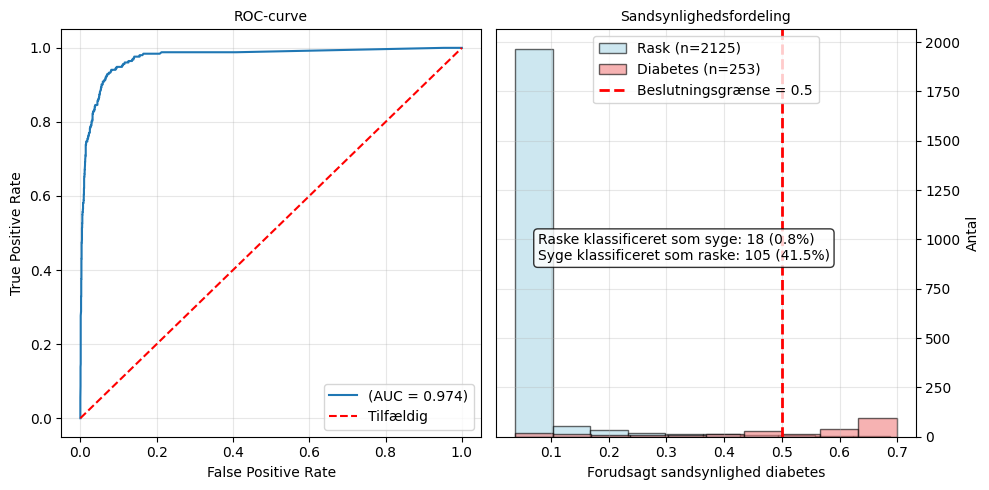

In [10]:
Plotting(sande_gruppe_test, forudsagte_score, forudsagte_gruppe, beslutningsgrænse)

### Spørgsmål:

- Prøv at ændre på hvor mange gange gange den må booste, ved at ændre boosting_rounds fra 1 til 10, 100 eller 1000. Kan du se en forbedring?
- Hvor laver modellen flest fejl? Raske der grupperes som diabetikere, eller omvendt?
- Som standard deler den ved 0.5 sandsynlighed. Kunne det være en fordel at dele ved en anden sandsynlighed? (Prøv evt. at ændre på beslutningsgrænsen oppe hvor modellen bliver trænet)
- Leg rundt med andelen af data du bruger. Hvordan ændres resultatet alt efter hvor meget data den har. Hvor meget data skal du bruge for at have en rimelig model og forudsigelse?

### Hvilke variabler er vigtigst?
Vi kan tjekke om vores intuition for hvilke variabler der er vigtigst med "permutation importance". Det er et mål for hvis værdierne i en kolonne bliver byttet tilfældigt rundt, hvor meget påvirker det så resultatet. Hvis det er en vigtig variabel, vil det påvirke resultatet meget. Her bliver det målt på hvor meget større mean squared error (fejlen) bliver, når den variabel bliver "scramblet".
- Er resultatet som du forventede?

In [ ]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names, but .* was fitted with feature names")

res = sklearn.inspection.permutation_importance(gbm_test, data_test, sande_gruppe_test, scoring="neg_mean_squared_error")

imp_mse = res.importances_mean                
order = np.argsort(imp_mse)[::-1]
labels = np.asarray(variabler[:-1])[order]
vals = imp_mse[order]

plt.figure(figsize=(8, 6))
y = np.arange(len(vals))
plt.barh(y, vals)
plt.yticks(y, labels)
plt.xlabel("Increase in log_loss (permutation)")
plt.ylabel("Feature")
plt.title("Permutation Importance")
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

# Neurale Netværk

Neurale Netværk (NN) kommer fra at opbygningen af dem, minder om den måde vores neuroner i hjernen snakker sammen på. På samme måde som et decision tree er der forskellige lag og vi kan styre hvor mange lag der er, men nu er det ikke kun sandt eller falsk, i stedet fungerer noderne som knapper der kan fintunes. 

Neurale netværk er mere følsomme overfor det data vi giver dem. Den fungerer bedst hvis værdierne i data er mellem 0 og 1. Derfor bruger vi en funktion til at skalere eller normalisere vores data, kaldet StandardScaler.

In [12]:
scaler = sklearn.preprocessing.StandardScaler()

data_træning_transformed = scaler.fit_transform(data_træning)
data_test_transformed = scaler.transform(data_test)

I et neuralt netværk kan vi justere på hvor mange lag og hvor mange noder hvert lag skal have:

In [32]:
layer_one   = 64            # Her definerer vi hvor mange lag der skal være, og hvor mange 'neuroner' eller noder 
layer_two   = 32            # hvert lag skal have. Prøv at ændre på antal noder 
layer_three = 16            # for at forbedre din model
layer_four  = 8
layer_five  = 4
layer_six   = 2

Nedenfor træner vi modellen. Vi kan også regne ud hvor mange parametre modellen bruger.
Herefter plotter vi for at se hvor godt modellen klarer sig.

In [ ]:
# Her definerer og træner vi modellen
mlp = sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(layer_one, layer_two, layer_three, layer_four, layer_five, layer_six), 
max_iter=2000, early_stopping=True, random_state=42)
mlp.fit(data_træning_transformed, sande_gruppe_træning) 

# Her giver vi den trænede model test data som den ikke har set før, og beder om at forudsige prisen
beslutningsgrænse = 0.5
forudsagte_gruppe = mlp.predict_proba(data_test_transformed)[:,1]  
forudsagte_gruppe = (forudsagte_gruppe > beslutningsgrænse).astype(int)
forudsagte_score = mlp.predict_proba(data_test_transformed)[:, 1]

# Beregn antal parametre i modellen
# Coef er vægtene er intercept er bias. Den henter antallet direkte fra modellen.
n_params = sum(coef.size + intercept.size for coef, intercept in zip(mlp.coefs_, mlp.intercepts_))
print(f"Antal parametre i NN: {n_params}")

Plotting(sande_gruppe_test, forudsagte_score, forudsagte_gruppe, beslutningsgrænse)

In [ ]:
#Tilføj egne værdier og se modellens forudsigelse.
input_values = {
    "Age": 40,
    "Resting_Heart_Rate": 100,
    "Weight": 110,
    "Mean_Blood_Sugar": 150,
    "Blood_Pressure": 80,
    "Cholesterol": 100,
    "Hours_of_Training": 2,
    "Height": 170
}

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names, but .* was fitted with feature names")
input_array = np.array([input_values[var] for var in input_variabler]).reshape(1, -1)
input_array = scaler.transform(input_array)
predicted_prob = mlp.predict_proba(input_array)[:, 1]
print(f"Den forudsagte sandsynlighed for diabetes er: {predicted_prob[0]:,.2f}.")


### Spørgsmål:
- Prøv at justere på antal neuroner i det neurale netværk - Kan du forbedre AUC og antallet at syge klassificeret som raske?
- Får du det samme antal parametre når du regner efter?
- Hvilken algoritme klarer sig bedst? Boosted decision tree eller neutralt netværk? Kan du få NN til at klare sig lige så godt som BDT?
- Prøv at justere på dit BDT og NN så de rammer samme AUC. Hvilken algoritme er så hurtigst?
- Leg rundt med andelen af data du bruger. Hvordan ændres resultatet alt efter hvor meget data den har. Hvor meget data skal du bruge for at have en rimelig model og forudsigelse?